In [ ]:
!pip install torch torchvision
!pip install git+https://github.com/chenyaofo/pytorch-cifar-models.git
!pip install torch torchvision
!pip install torchattacks

  Cloning https://github.com/chenyaofo/pytorch-cifar-models.git to /tmp/pip-req-build-_ypm97k5
  Running command git clone --filter=blob:none --quiet https://github.com/chenyaofo/pytorch-cifar-models.git /tmp/pip-req-build-_ypm97k5
  Resolved https://github.com/chenyaofo/pytorch-cifar-models.git to commit d1c8e99b911da7d412979600c84d2a4fe3728473
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 7.8 MB/s eta 0:00:00
   ━━━━

In [ ]:
# 2. imports & device
import torch
import torchvision
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on", device)

# 3. CIFAR-10 normalization and loaders
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.CIFAR10(root='./data',
                            train=True,
                            download=True,
                            transform=transform)
test_ds  = datasets.CIFAR10(root='./data',
                            train=False,
                            download=True,
                            transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=128, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(
    test_ds,  batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
print(f"Loaded CIFAR-10, {len(train_ds)} train / {len(test_ds)} test examples")


Running on cuda


100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


Loaded CIFAR-10, 50000 train / 10000 test examples


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch

model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
)
model = model.to(device)
model.eval()


/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt
100%|██████████| 1.09M/1.09M [00:00<00:00, 28.9MB/s

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [ ]:
# imports & device
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import torchattacks

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("→ Device:", device)


→ Device: cuda


### Part1: Data Augmentation

In [ ]:
#  CIFAR-10 w/ 50% augmentation
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# clean pipeline
clean_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# augmentation pipeline (jitter + rotate), then noise, then normalize
aug_pre = transforms.Compose([
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
def add_noise(x, noise_std=0.1):
    return x + torch.randn_like(x) * noise_std

aug_tf = transforms.Compose([
    aug_pre,
    transforms.Lambda(lambda x: add_noise(x, noise_std=0.1)),
    transforms.Normalize(mean, std),
])

class HalfAugmentedCIFAR(Dataset):
    def __init__(self, train=True):
        self.base = datasets.CIFAR10('./data', train=train, download=True)
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, label = self.base[i]
        # 50% chance to augment
        if random.random() < 0.5:
            x = aug_tf(img)
        else:
            x = clean_tf(img)
        return x, label

train_ds = HalfAugmentedCIFAR(train=True)
test_ds  = datasets.CIFAR10('./data', train=False, download=True,
                            transform=clean_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")


Train size: 50000, Test size: 10000


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# load pretrained ResNet-20
model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device)
print(model)


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [ ]:
# training loop
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01,
                      momentum=0.9, weight_decay=5e-4)

epochs = 10
for ep in range(1, epochs+1):
    model.train()
    running_loss = 0.
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {ep}/{epochs}, loss {avg_loss:.4f}")


Epoch 1/10, loss 0.6738
Epoch 2/10, loss 0.5280
Epoch 3/10, loss 0.4938
Epoch 4/10, loss 0.4720
Epoch 5/10, loss 0.4508
Epoch 6/10, loss 0.4387
Epoch 7/10, loss 0.4236
Epoch 8/10, loss 0.4086
Epoch 9/10, loss 0.4049
Epoch 10/10, loss 0.4011


In [ ]:
# define FGSM & PGD attackers
eps   = 0.03    # L∞ bound
alpha = 0.005   # PGD step size
steps = 40      # PGD steps

fgsm = torchattacks.FGSM(model, eps=eps)
pgd  = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=steps)


In [ ]:
model.eval()
clean_acc = fgsm_acc = pgd_acc = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        total += xb.size(0)

        # clean
        clean_preds = model(xb).argmax(1)
        clean_acc += (clean_preds == yb).sum().item()

        # FGSM
        with torch.enable_grad():
            adv1 = fgsm(xb, yb)
        fgsm_preds = model(adv1).argmax(1)
        fgsm_acc += (fgsm_preds == yb).sum().item()

        # PGD
        with torch.enable_grad():
            adv2 = pgd(xb, yb)
        pgd_preds = model(adv2).argmax(1)
        pgd_acc += (pgd_preds == yb).sum().item()

print(f"Clean: {clean_acc/total:.4f}")
print(f"FGSM:  {fgsm_acc/total:.4f}")
print(f"PGD:   {pgd_acc/total:.4f}")


Clean: 0.8775
FGSM:  0.4542
PGD:   0.2812


In [ ]:
# compute percentages
clean_pct = 100.0 * clean_acc / total
fgsm_pct  = 100.0 * fgsm_acc  / total
pgd_pct   = 100.0 * pgd_acc   / total

print(f"Clean accuracy: {clean_pct:.2f}%")
print(f"FGSM accuracy:  {fgsm_pct:.2f}%")
print(f"PGD accuracy:   {pgd_pct:.2f}%")

Clean accuracy: 87.75%
FGSM accuracy:  45.42%
PGD accuracy:   28.12%


In [ ]:
# install UMAP
!pip install umap-learn


In [ ]:
# extract feature vectors
import torch
import umap
import matplotlib.pyplot as plt

# 1) define a feature‐only model by chopping off the last (FC) layer
#    for ResNet-20 from the hub we can do:
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
feature_extractor.eval()

# 2) collect features & labels for clean, FGSM, PGD
feats_clean, labels_clean = [], []
feats_fgsm,  labels_fgsm  = [], []
feats_pgd,   labels_pgd   = [], []

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    # — clean
    with torch.no_grad():
        f = feature_extractor(xb).view(xb.size(0), -1)
    feats_clean.append(f.cpu());  labels_clean.append(yb.cpu())
    # — FGSM
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        f1 = feature_extractor(adv1).view(xb.size(0), -1)
    feats_fgsm.append(f1.cpu());  labels_fgsm.append(yb.cpu())
    # — PGD
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        f2 = feature_extractor(adv2).view(xb.size(0), -1)
    feats_pgd.append(f2.cpu());   labels_pgd.append(yb.cpu())

# stack into arrays
feats_clean = torch.cat(feats_clean).numpy()
labels_clean = torch.cat(labels_clean).numpy()
feats_fgsm  = torch.cat(feats_fgsm).numpy()
labels_fgsm  = torch.cat(labels_fgsm).numpy()
feats_pgd   = torch.cat(feats_pgd).numpy()
labels_pgd   = torch.cat(labels_pgd).numpy()


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


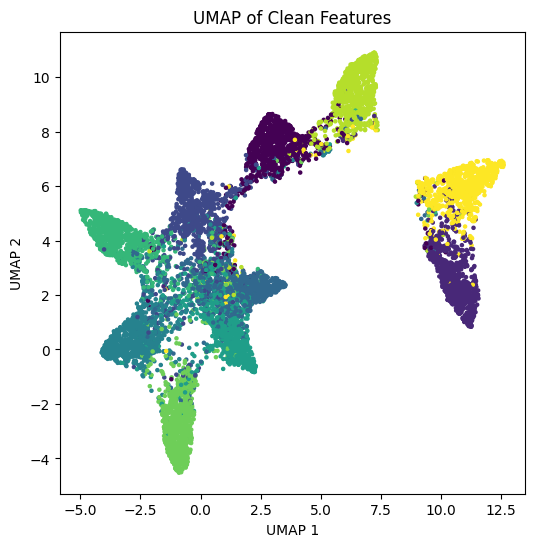

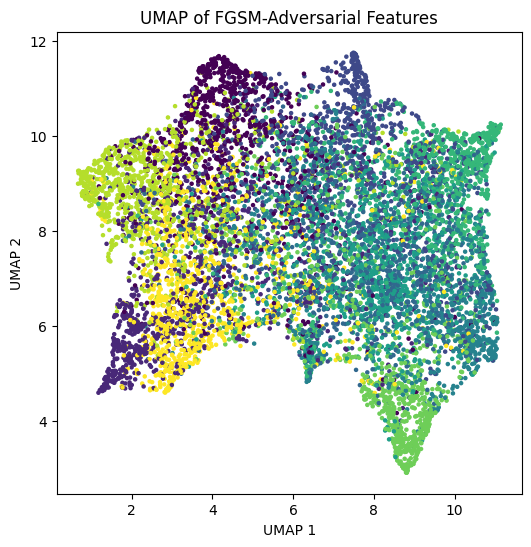

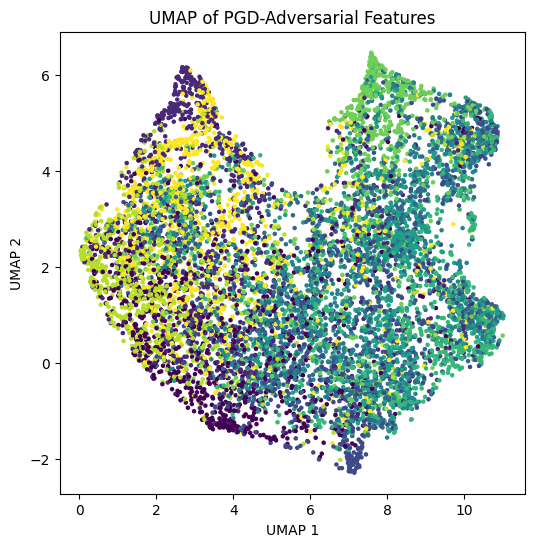

In [ ]:
# Cell 10 — run UMAP + plot each in 2D
# we'll fit three separate 2D embeddings (one per set)
reducer = umap.UMAP(n_components=2, random_state=42)

emb_clean = reducer.fit_transform(feats_clean)
emb_fgsm  = reducer.fit_transform(feats_fgsm)
emb_pgd   = reducer.fit_transform(feats_pgd)

# 3 separate scatter plots
for emb, lbls, title in [
    (emb_clean, labels_clean, "UMAP of Clean Features"),
    (emb_fgsm,  labels_fgsm,  "UMAP of FGSM-Adversarial Features"),
    (emb_pgd,   labels_pgd,   "UMAP of PGD-Adversarial Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)  # uses default colormap
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()


### part 2: ADVERSARIAL TRAINING

In [ ]:
# imports & hyperparams
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets
import torchattacks
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# FGSM/PGD settings
eps   = 0.03
alpha = 0.005
steps = 40

# training settings
batch_size = 128
lr         = 0.01
epochs     = 10

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)


In [ ]:
#  data + model
# CIFAR-10 loaders (clean)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean,std)])
train_ds = datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# pretrained ResNet-20
model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

# attacker for adversarial training (FGSM)
adv_train = torchattacks.FGSM(model, eps=eps)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [ ]:
#  adversarial training loop (50% FGSM per batch)
train_losses = []

model.train()
for ep in range(1, epochs+1):
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        bs = xb.size(0)

        # pick half of the batch to perturb
        idx = torch.randperm(bs)[: bs//2]
        xb_adv = xb.clone()
        # generate adversarial on those indices
        xb_adv[idx] = adv_train(xb[idx], yb[idx])

        # forward on mixed inputs
        optimizer.zero_grad()
        logits = model(xb_adv)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * bs

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {ep}/{epochs} — loss: {epoch_loss:.4f}")


Epoch 1/10 — loss: 0.6776
Epoch 2/10 — loss: 0.5305
Epoch 3/10 — loss: 0.4839
Epoch 4/10 — loss: 0.4575
Epoch 5/10 — loss: 0.4297
Epoch 6/10 — loss: 0.4109
Epoch 7/10 — loss: 0.3916
Epoch 8/10 — loss: 0.3784
Epoch 9/10 — loss: 0.3634
Epoch 10/10 — loss: 0.3577


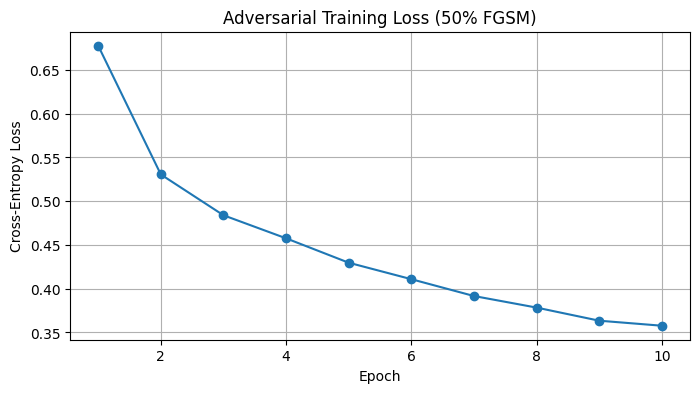

In [ ]:
#  plot training loss
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Adversarial Training Loss (50% FGSM)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()


In [ ]:
# evaluation on clean, FGSM & PGD
# re-define attackers (model now updated)
fgsm = torchattacks.FGSM(model, eps=eps)
pgd  = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=steps)

model.eval()
clean_acc = fgsm_acc = pgd_acc = 0
total = 0

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    total += yb.size(0)

    # clean
    with torch.no_grad():
        preds = model(xb).argmax(dim=1)
    clean_acc += (preds == yb).sum().item()

    # FGSM
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        preds1 = model(adv1).argmax(dim=1)
    fgsm_acc += (preds1 == yb).sum().item()

    # PGD
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        preds2 = model(adv2).argmax(dim=1)
    pgd_acc += (preds2 == yb).sum().item()

clean_pct = 100.0 * clean_acc / total
fgsm_pct  = 100.0 * fgsm_acc  / total
pgd_pct   = 100.0 * pgd_acc   / total

print(f"Clean accuracy: {clean_pct:.2f}%")
print(f"FGSM accuracy:  {fgsm_pct:.2f}%")
print(f"PGD accuracy:   {pgd_pct:.2f}%")


Clean accuracy: 88.81%
FGSM accuracy:  69.76%
PGD accuracy:   50.37%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


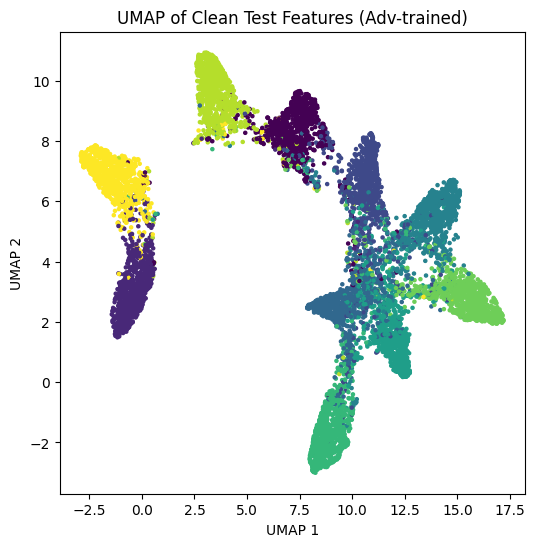

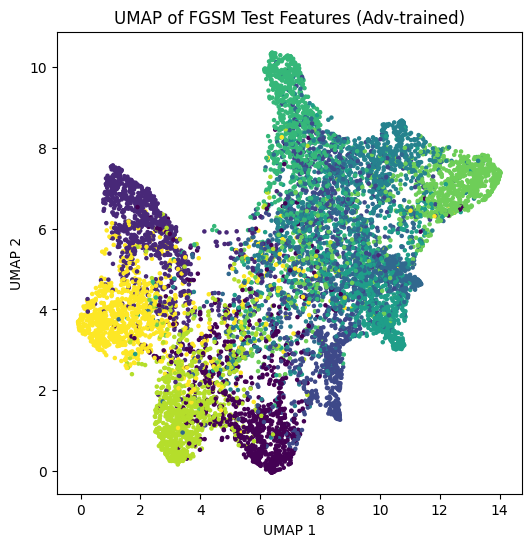

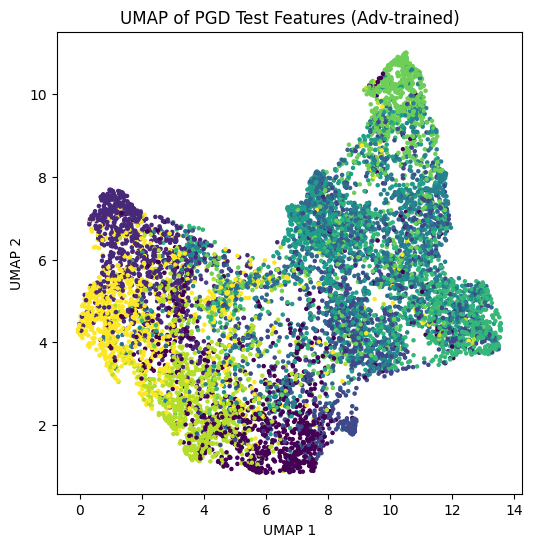

In [ ]:
# extract features from the adversarially-trained model
import torch
import umap
import matplotlib.pyplot as plt

# 1) build a feature‐only extractor by removing the final FC
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
feature_extractor.eval()

# 2) gather clean, FGSM, and PGD feature vectors & labels
feats_clean, labels_clean = [], []
feats_fgsm,  labels_fgsm  = [], []
feats_pgd,   labels_pgd   = [], []

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    bs = xb.size(0)

    # clean
    with torch.no_grad():
        f = feature_extractor(xb).view(bs, -1)
    feats_clean.append(f.cpu());  labels_clean.append(yb.cpu())

    # FGSM
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        f1 = feature_extractor(adv1).view(bs, -1)
    feats_fgsm.append(f1.cpu());  labels_fgsm.append(yb.cpu())

    # PGD
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        f2 = feature_extractor(adv2).view(bs, -1)
    feats_pgd.append(f2.cpu());   labels_pgd.append(yb.cpu())

# stack into single arrays
feats_clean = torch.cat(feats_clean).numpy()
labels_clean = torch.cat(labels_clean).numpy()
feats_fgsm  = torch.cat(feats_fgsm).numpy()
labels_fgsm  = torch.cat(labels_fgsm).numpy()
feats_pgd   = torch.cat(feats_pgd).numpy()
labels_pgd   = torch.cat(labels_pgd).numpy()

# 3) run and plot UMAPs
reducer = umap.UMAP(n_components=2, random_state=42)

emb_clean = reducer.fit_transform(feats_clean)
emb_fgsm  = reducer.fit_transform(feats_fgsm)
emb_pgd   = reducer.fit_transform(feats_pgd)

for emb, lbls, title in [
    (emb_clean, labels_clean, "UMAP of Clean Test Features (Adv-trained)"),
    (emb_fgsm,  labels_fgsm,  "UMAP of FGSM Test Features (Adv-trained)"),
    (emb_pgd,   labels_pgd,   "UMAP of PGD Test Features (Adv-trained)"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()


### part 3: CONTRASTIVE LEARNING

In [ ]:
# install deps
!pip install torch torchvision torchattacks pytorch-metric-learning umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 5.9 MB/s eta 0:00:00


In [ ]:
# imports & hyperparameters
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets
import torchattacks
from pytorch_metric_learning.losses import CircleLoss
import matplotlib.pyplot as plt
import umap

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# attack & training settings
eps       = 0.03    # FGSM/PGD ε
alpha     = 0.005   # PGD step size
pgd_steps = 40

batch_size=128
epochs    = 10
lr        = 0.01
lambda_c  = 1.0     # weight for CircleLoss

mean = (0.4914,0.4822,0.4465); std=(0.2023,0.1994,0.2010)


In [ ]:
# data loaders
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean,std)])
train_ds = datasets.CIFAR10('./data', train=True,  download=True, transform=tf)
test_ds  = datasets.CIFAR10('./data', train=False, download=True, transform=tf)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# model + feature extractor
# load pretrained ResNet-20 with its FC head
model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device)

# feature extractor = everything up to avgpool
backbone = nn.Sequential(*list(model.children())[:-1], nn.Flatten()).to(device)
# (64-dim features for ResNet-20 CIFAR)
# we'll still use model(x) for logits & attacks, but extract feats via backbone(x)

# sanity check
_ = backbone(torch.randn(2,3,32,32, device=device))  # -> [2,64]


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [ ]:
# losses & optimizer
criterion_ce     = nn.CrossEntropyLoss()
criterion_circle = CircleLoss(m=0.25, gamma=256).to(device)
optimizer        = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)


In [ ]:
# training loop (CE + Circle)
train_losses = []

model.train()
for ep in range(1, epochs+1):
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # forward
        logits = model(xb)
        feats  = backbone(xb)    # [B,64]

        loss_ce     = criterion_ce(logits, yb)
        loss_circle = criterion_circle(feats, yb)
        loss        = loss_ce + lambda_c * loss_circle

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {ep}/{epochs} — combined loss: {epoch_loss:.4f}")


Epoch 1/10 — combined loss: 225.0695
Epoch 2/10 — combined loss: 205.8492
Epoch 3/10 — combined loss: 184.8760
Epoch 4/10 — combined loss: 178.1404
Epoch 5/10 — combined loss: 175.8044
Epoch 6/10 — combined loss: 174.2603
Epoch 7/10 — combined loss: 173.0219
Epoch 8/10 — combined loss: 172.1990
Epoch 9/10 — combined loss: 171.5858
Epoch 10/10 — combined loss: 171.1367


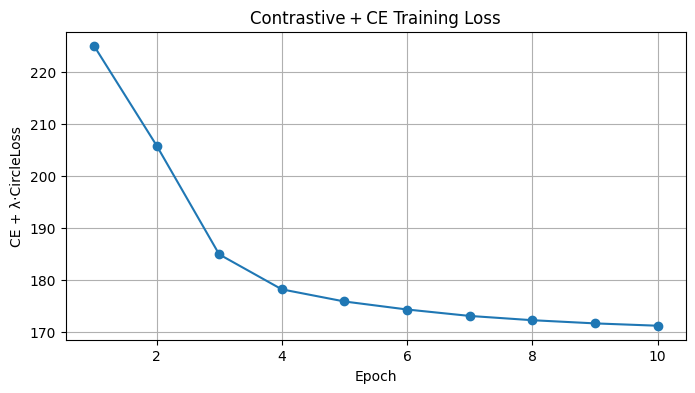

In [ ]:
# plot training loss
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Contrastive + CE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("CE + λ·CircleLoss")
plt.grid(True)
plt.show()


In [ ]:
# define FGSM & PGD on the trained classifier
fgsm = torchattacks.FGSM(model, eps=eps)
pgd  = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=pgd_steps)


In [ ]:
# classification eval with proper grad for attacks
model.eval()
fgsm = torchattacks.FGSM(model, eps=eps)
pgd  = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=pgd_steps)

total = clean_acc = fgsm_acc = pgd_acc = 0

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    batch_n = yb.size(0)
    total += batch_n

    # — clean
    with torch.no_grad():
        clean_preds = model(xb).argmax(dim=1)
    clean_acc += (clean_preds == yb).sum().item()

    # — FGSM (grad ON)
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        fgsm_preds = model(adv1).argmax(dim=1)
    fgsm_acc += (fgsm_preds == yb).sum().item()

    # — PGD (grad ON)
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        pgd_preds = model(adv2).argmax(dim=1)
    pgd_acc += (pgd_preds == yb).sum().item()

# percentages
print(f"Clean accuracy: {100*clean_acc/total:.2f}%")
print(f"FGSM accuracy:  {100*fgsm_acc/total:.2f}%")
print(f"PGD accuracy:   {100*pgd_acc/total:.2f}%")


Clean accuracy: 29.47%
FGSM accuracy:  13.88%
PGD accuracy:   7.17%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


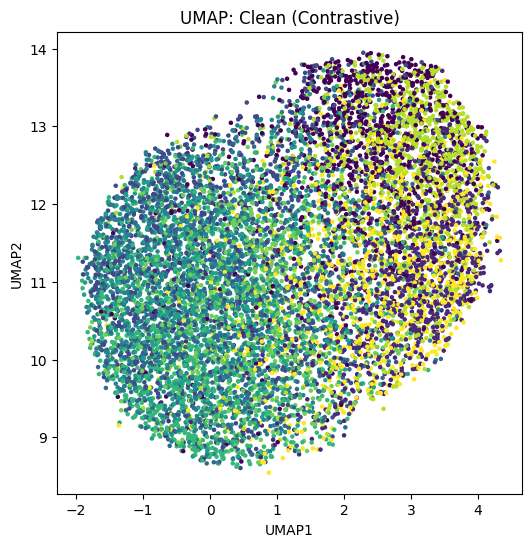

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


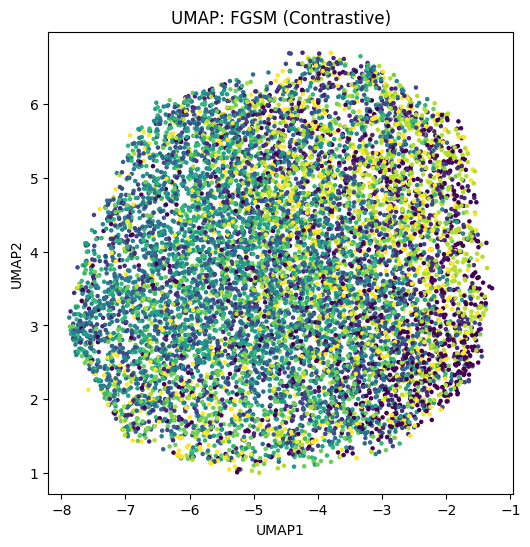

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


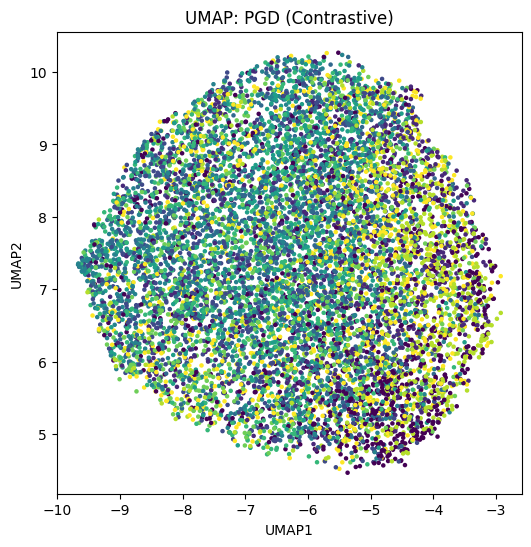

In [ ]:
# UMAP extraction with proper grad for attacks
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1],
                                        torch.nn.Flatten()).to(device)
feature_extractor.eval()

feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)

    # clean
    with torch.no_grad():
        feats_c.append(feature_extractor(xb).cpu())
        lbls_c.append(yb.cpu())

    # FGSM (grad ON)
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        feats_f.append(feature_extractor(adv1).cpu())
        lbls_f.append(yb.cpu())

    # PGD (grad ON)
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        feats_p.append(feature_extractor(adv2).cpu())
        lbls_p.append(yb.cpu())

# stack and run UMAP
import numpy as np
feats_c = np.vstack([f.numpy() for f in feats_c]); lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]); lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]); lbls_p = np.hstack(lbls_p)

import umap, matplotlib.pyplot as plt
reducer = umap.UMAP(n_components=2, random_state=42)
for feats, lbls, title in [
    (feats_c, lbls_c, "UMAP: Clean (Contrastive)"),
    (feats_f, lbls_f, "UMAP: FGSM (Contrastive)"),
    (feats_p, lbls_p, "UMAP: PGD (Contrastive)"),
]:
    emb = reducer.fit_transform(feats)
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()


In [ ]:
# pure CircleLoss & optimizer
criterion = CircleLoss(m=0.25, gamma=256).to(device)
optimizer = optim.SGD(
    backbone.parameters(),  # only update the backbone
    lr=lr,
    momentum=0.9,
    weight_decay=5e-4
)


In [ ]:
# training loop (CircleLoss only)
train_losses = []
epochs = 20
for ep in range(1, epochs+1):
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        feats = backbone(xb)               # [B,64]
        loss  = criterion(feats, yb)       # CircleLoss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)

    epoch_loss = running / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {ep}/{epochs} — CircleLoss: {epoch_loss:.4f}")


Epoch 1/20 — CircleLoss: 167.0879
Epoch 2/20 — CircleLoss: 167.1049
Epoch 3/20 — CircleLoss: 167.0394
Epoch 4/20 — CircleLoss: 166.8647
Epoch 5/20 — CircleLoss: 166.2801
Epoch 6/20 — CircleLoss: 166.3836
Epoch 7/20 — CircleLoss: 166.1249
Epoch 8/20 — CircleLoss: 165.8199
Epoch 9/20 — CircleLoss: 165.6927
Epoch 10/20 — CircleLoss: 165.4096
Epoch 11/20 — CircleLoss: 165.2064
Epoch 12/20 — CircleLoss: 165.2436
Epoch 13/20 — CircleLoss: 164.9145
Epoch 14/20 — CircleLoss: 164.9692
Epoch 15/20 — CircleLoss: 164.5828
Epoch 16/20 — CircleLoss: 164.5357
Epoch 17/20 — CircleLoss: 164.3060
Epoch 18/20 — CircleLoss: 164.2774
Epoch 19/20 — CircleLoss: 164.1117
Epoch 20/20 — CircleLoss: 163.9571


In [44]:
# right after training completes
torch.save(backbone.state_dict(), "circle_backbone.pth")


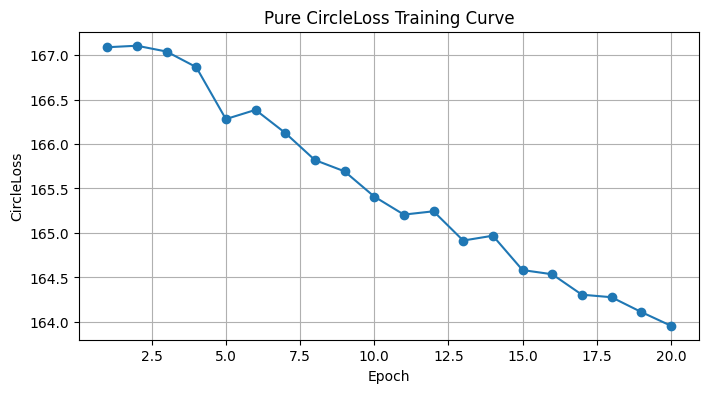

In [ ]:
# plot training loss
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Pure CircleLoss Training Curve")
plt.xlabel("Epoch")
plt.ylabel("CircleLoss")
plt.grid(True)
plt.show()


In [ ]:
# define FGSM & PGD attackers on the full model
# (backbone + frozen FC still form a classifier)
fgsm = torchattacks.FGSM(model, eps=eps)
pgd  = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=pgd_steps)


In [ ]:
# classification evaluation (clean, FGSM, PGD)
model.eval()
total = clean_acc = fgsm_acc = pgd_acc = 0

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    bs = yb.size(0)
    total += bs

    # —— clean
    with torch.no_grad():
        preds = model(xb).argmax(dim=1)
    clean_acc += (preds == yb).sum().item()

    # —— FGSM (grad ON)
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        p1 = model(adv1).argmax(dim=1)
    fgsm_acc += (p1 == yb).sum().item()

    # —— PGD (grad ON)
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        p2 = model(adv2).argmax(dim=1)
    pgd_acc += (p2 == yb).sum().item()

print(f"Clean accuracy: {100*clean_acc/total:.2f}%")
print(f"FGSM accuracy:  {100*fgsm_acc/total:.2f}%")
print(f"PGD accuracy:   {100*pgd_acc/total:.2f}%")


Clean accuracy: 28.12%
FGSM accuracy:  11.72%
PGD accuracy:   4.89%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


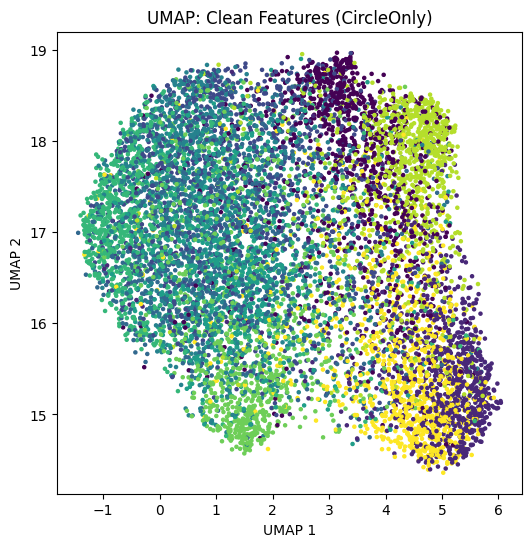

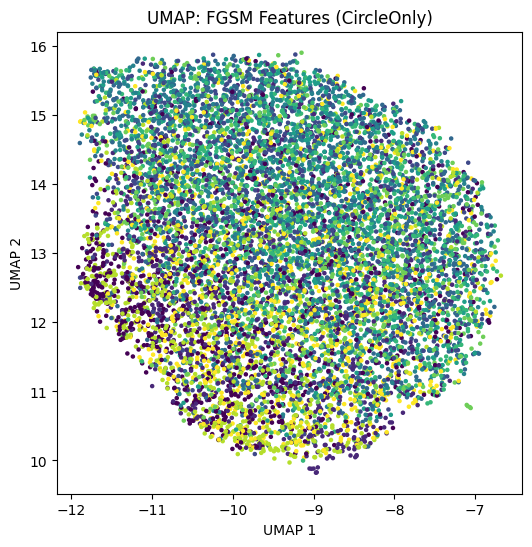

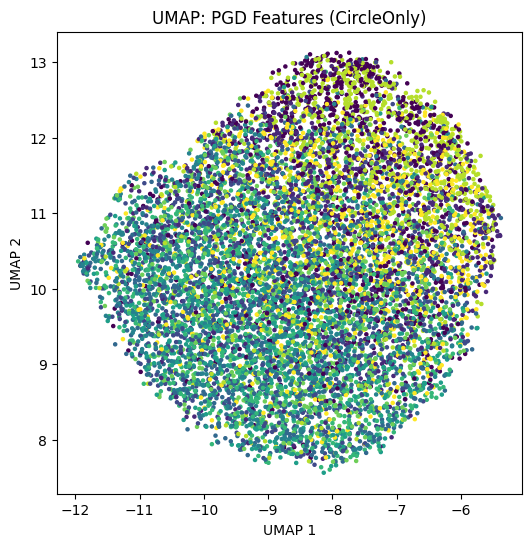

In [ ]:
# extract embeddings & plot UMAPs (clean, FGSM, PGD)
backbone.eval()

feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)

    # clean embeddings
    with torch.no_grad():
        feats_c.append(backbone(xb).cpu()); lbls_c.append(yb.cpu())

    # FGSM embeddings
    adv1 = fgsm(xb, yb)
    with torch.no_grad():
        feats_f.append(backbone(adv1).cpu()); lbls_f.append(yb.cpu())

    # PGD embeddings
    adv2 = pgd(xb, yb)
    with torch.no_grad():
        feats_p.append(backbone(adv2).cpu()); lbls_p.append(yb.cpu())

import numpy as np
feats_c = np.vstack([f.numpy() for f in feats_c]); lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]); lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]); lbls_p = np.hstack(lbls_p)

reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Clean Features (CircleOnly)"),
    (emb_f, lbls_f, "UMAP: FGSM Features (CircleOnly)"),
    (emb_p, lbls_p, "UMAP: PGD Features (CircleOnly)"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


### Part 4: DEFENSIVE VAE

In [1]:
# install
!pip install torch torchvision torchattacks umap-learn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [19]:
import torch
import torch.nn as nn


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # [B, 32, 16, 16]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # [B, 64, 8, 8]
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),# [B, 128, 4, 4]
            nn.ReLU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # [B, 64, 8, 8]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # [B, 32, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # [B, 3, 32, 32]
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon


In [ ]:
# imports, hyperparams & models
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets
import torchattacks
import umap
import matplotlib.pyplot as plt


device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eps       = 0.03      # FGSM ε
batch_size=128
epochs    = 10
lr_ae     = 1e-3

# normalization stats
mean = (0.4914,0.4822,0.4465)
std  = (0.2023,0.1994,0.2010)
normalize = transforms.Normalize(mean,std)
# tensors for unnormalize
mean_t = torch.tensor(mean).view(1,3,1,1).to(device)
std_t  = torch.tensor(std).view(1,3,1,1).to(device)
def unnormalize(x):
    return x * std_t + mean_t

# pretrained classifier for attack & eval
classifier = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device).eval()
fgsm = torchattacks.FGSM(classifier, eps=eps)

# autoencoder
ae = Autoencoder().to(device)
optimizer_ae = optim.Adam(ae.parameters(), lr=lr_ae)
criterion_ae = nn.MSELoss()


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [ ]:
# dataloaders (raw images only)
tf_raw = transforms.ToTensor()
train_ds_raw = datasets.CIFAR10('./data', train=True,  download=True, transform=tf_raw)
test_ds_raw  = datasets.CIFAR10('./data', train=False, download=True, transform=tf_raw)
train_loader = DataLoader(train_ds_raw, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds_raw,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# train AE: input = FGSM-disturbed (unnorm), target = clean raw
train_losses_ae = []
ae.train()
for ep in range(1, epochs+1):
    running = 0.0
    for xb_raw, yb in train_loader:
        xb_raw = xb_raw.to(device)
        yb      = yb.to(device)

        # make adversarial on normalized
        xb_norm = normalize(xb_raw)
        adv_norm = fgsm(xb_norm, yb)
        xb_adv_raw = unnormalize(adv_norm).clamp(0,1)

        # AE forward + loss
        recon = ae(xb_adv_raw)
        loss  = criterion_ae(recon, xb_raw)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        running += loss.item() * xb_raw.size(0)

    epoch_loss = running / len(train_loader.dataset)
    train_losses_ae.append(epoch_loss)
    print(f"Epoch {ep}/{epochs}  AE MSE: {epoch_loss:.4f}")


Epoch 1/10  AE MSE: 0.0279
Epoch 2/10  AE MSE: 0.0167
Epoch 3/10  AE MSE: 0.0151
Epoch 4/10  AE MSE: 0.0140
Epoch 5/10  AE MSE: 0.0134
Epoch 6/10  AE MSE: 0.0125
Epoch 7/10  AE MSE: 0.0121
Epoch 8/10  AE MSE: 0.0119
Epoch 9/10  AE MSE: 0.0115
Epoch 10/10  AE MSE: 0.0113


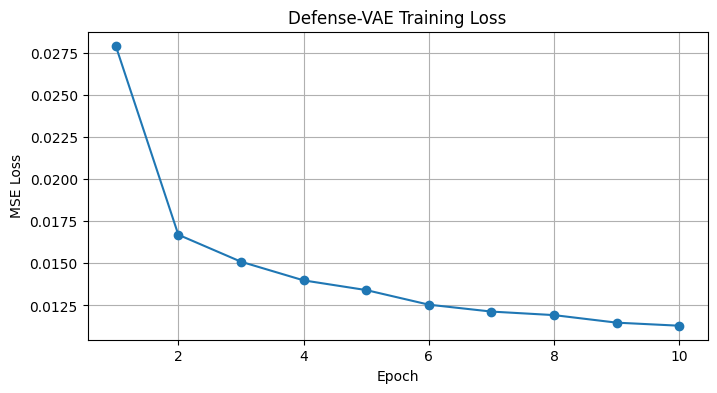

In [ ]:
# plot AE training loss
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses_ae, marker='o')
plt.title("Defense-VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [ ]:
#  eval defense accuracy on clean, FGSM & PGD
import torchattacks

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

ae.eval()
classifier.eval()

total = clean_def = fgsm_def = pgd_def = 0

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)
    bs = yb.size(0)
    total += bs

    # — clean → AE → classifier
    with torch.no_grad():
        recon_c = ae(xb_raw)
        inp_c   = normalize(recon_c)
        preds_c = classifier(inp_c).argmax(1)
    clean_def += (preds_c == yb).sum().item()

    # — FGSM → AE → classifier
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_a1 = ae(adv_raw1)
        inp_a1   = normalize(recon_a1)
        preds_a1 = classifier(inp_a1).argmax(1)
    fgsm_def += (preds_a1 == yb).sum().item()

    # — PGD → AE → classifier
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_a2 = ae(adv_raw2)
        inp_a2   = normalize(recon_a2)
        preds_a2 = classifier(inp_a2).argmax(1)
    pgd_def += (preds_a2 == yb).sum().item()

# compute percentages
clean_pct = 100 * clean_def / total
fgsm_pct  = 100 * fgsm_def  / total
pgd_pct   = 100 * pgd_def   / total

print(f"Defended Clean acc: {clean_pct:.2f}%")
print(f"Defended FGSM acc:  {fgsm_pct:.2f}%")
print(f"Defended PGD acc:   {pgd_pct:.2f}%")


Defended Clean acc: 38.78%
Defended FGSM acc:  24.34%
Defended PGD acc:   24.23%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


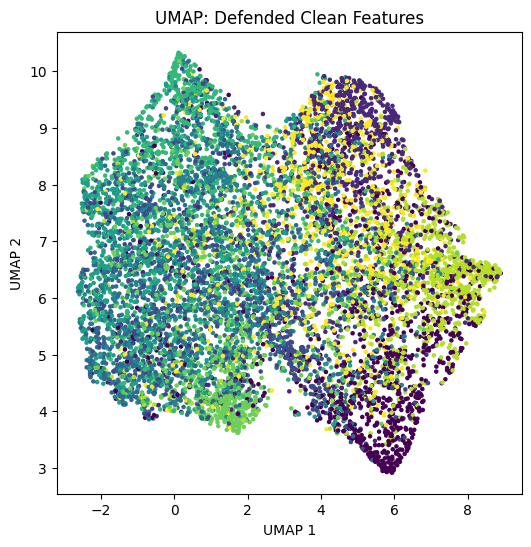

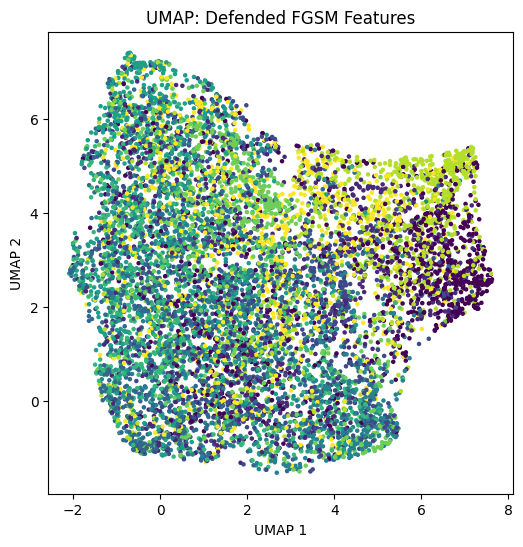

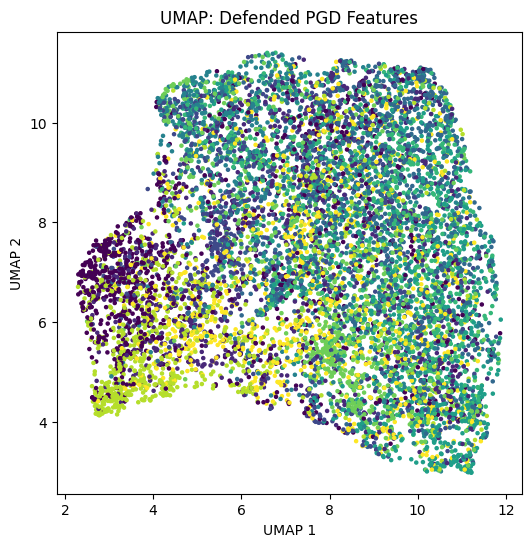

In [ ]:
# UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


In [26]:
import torch.nn as nn

# define CE loss
ce_criterion = nn.CrossEntropyLoss()

# unfreeze only the classifier head
for name, p in classifier.named_parameters():
    p.requires_grad = name.startswith("fc.")

opt_clf = torch.optim.SGD(classifier.parameters(), lr=1e-3, momentum=0.9)

# now your fine-tuning loop
for ep in range(1, epochs+1):
    classifier.train()
    total_loss = 0.0
    for x_raw, y in train_loader:
        x_raw, y = x_raw.to(device), y.to(device)

        with torch.no_grad():
            x_rec = ae(x_raw)              # get reconstructed images

        logits = classifier(normalize(x_rec))
        loss   = ce_criterion(logits, y)  # ← now defined!

        opt_clf.zero_grad()
        loss.backward()
        opt_clf.step()

        total_loss += loss.item() * x_raw.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Fine‐tune epoch {ep}, CE loss {avg_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Fine‐tune epoch 1, CE loss 2.7308
Fine‐tune epoch 2, CE loss 2.3758
Fine‐tune epoch 3, CE loss 2.0862
Fine‐tune epoch 4, CE loss 1.8713
Fine‐tune epoch 5, CE loss 1.7290
Fine‐tune epoch 6, CE loss 1.6535
Fine‐tune epoch 7, CE loss 1.6164
Fine‐tune epoch 8, CE loss 1.6001
Fine‐tune epoch 9, CE loss 1.5932
Fine‐tune epoch 10, CE loss 1.5901


In [27]:
# Evaluation on clean, FGSM- and PGD-perturbed via AE → classifier

import torch
import torchattacks

# ensure PGD attacker is defined
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

classifier.eval()
ae.eval()

total = clean_corr = fgsm_corr = pgd_corr = 0

for x_raw, y in test_loader:
    x_raw, y = x_raw.to(device), y.to(device)
    bs = y.size(0)
    total += bs

    # — Clean
    with torch.no_grad():
        x_rec     = ae(x_raw)                            # Reconstruct clean
        logits_c  = classifier(normalize(x_rec))        # Classify
        preds_c   = logits_c.argmax(dim=1)
    clean_corr += (preds_c == y).sum().item()

    # — FGSM
    x_norm     = normalize(x_raw)
    adv_norm1  = fgsm(x_norm, y)                       # FGSM on normalized
    x_adv_raw1 = unnormalize(adv_norm1).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec1     = ae(x_adv_raw1)                    # Reconstruct FGSM
        logits_fgsm= classifier(normalize(x_rec1))
        preds_fgsm = logits_fgsm.argmax(dim=1)
    fgsm_corr += (preds_fgsm == y).sum().item()

    # — PGD
    adv_norm2  = pgd(x_norm, y)                        # PGD on normalized
    x_adv_raw2 = unnormalize(adv_norm2).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec2     = ae(x_adv_raw2)                    # Reconstruct PGD
        logits_pgd = classifier(normalize(x_rec2))
        preds_pgd  = logits_pgd.argmax(dim=1)
    pgd_corr += (preds_pgd == y).sum().item()

# compute percentages
clean_acc = 100 * clean_corr / total
fgsm_acc  = 100 * fgsm_corr  / total
pgd_acc   = 100 * pgd_corr   / total

print(f"Defended Clean accuracy: {clean_acc:.2f}%")
print(f"Defended FGSM accuracy:  {fgsm_acc:.2f}%")
print(f"Defended PGD accuracy:   {pgd_acc:.2f}%")


Defended Clean accuracy: 44.95%
Defended FGSM accuracy:  31.23%
Defended PGD accuracy:   31.13%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


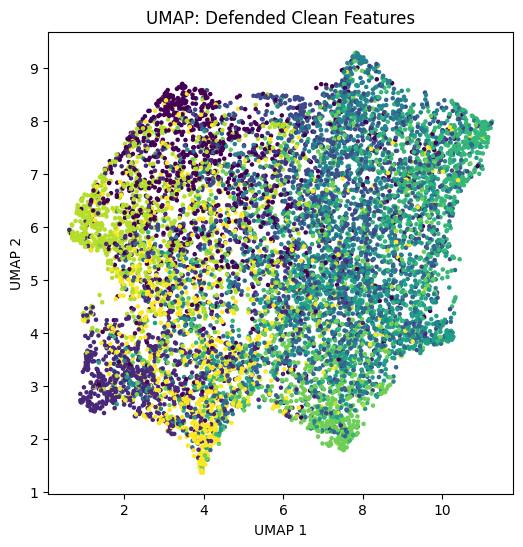

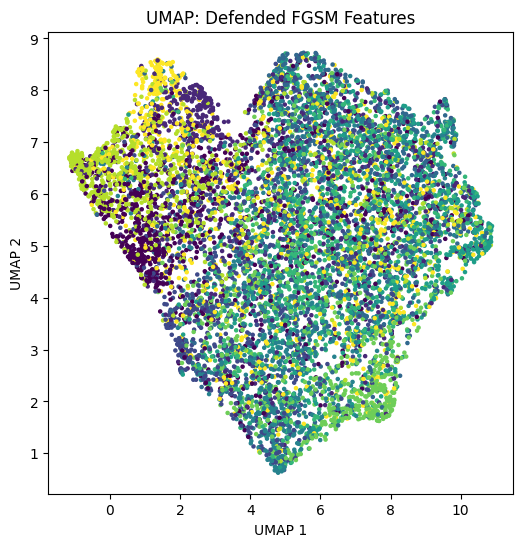

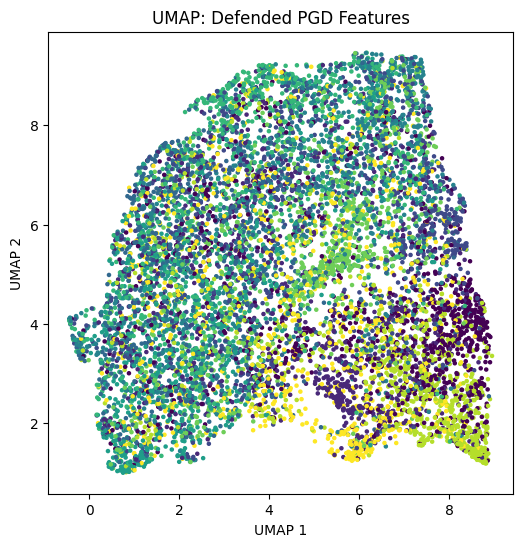

In [28]:
# Cell 7 — UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warn

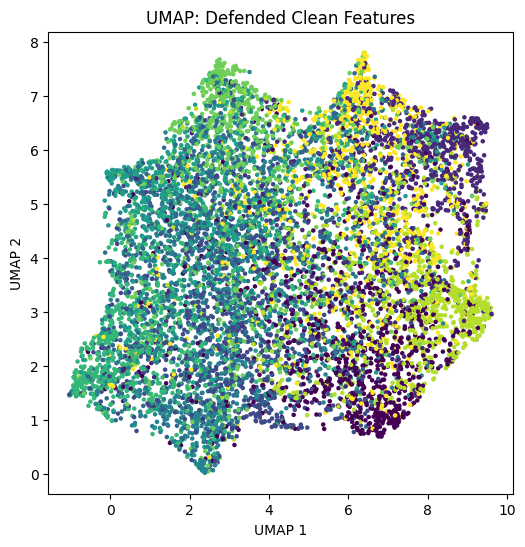

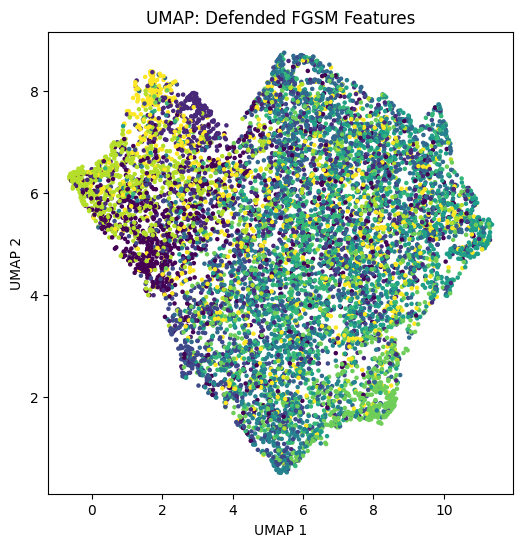

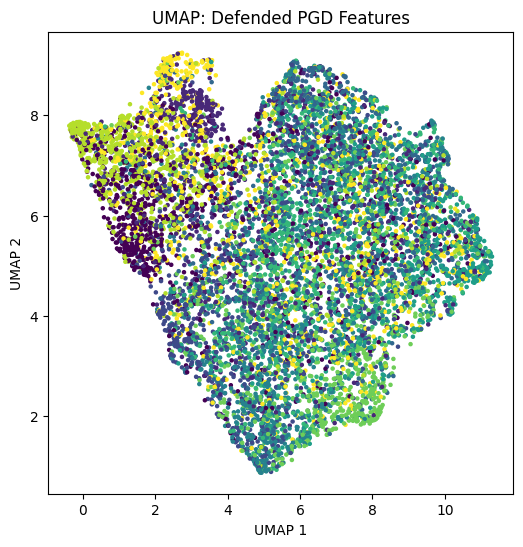

In [29]:
# Cell 7 — UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


In [30]:
import torch.nn as nn

# Reconstruction and classification losses
mse_criterion = nn.MSELoss()
ce_criterion  = nn.CrossEntropyLoss()

# If you hadn’t already:
optimizer_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)
lambda_ce    = 1.0

# Joint AE + CE training loop
for ep in range(1, epochs+1):
    ae.train()
    running = 0.0
    for x_raw, y in train_loader:
        x_raw, y = x_raw.to(device), y.to(device)

        # 1) Generate FGSM adversarial raw input
        x_norm    = normalize(x_raw)
        adv_norm  = fgsm(x_norm, y)
        x_adv_raw = unnormalize(adv_norm).clamp(0,1)

        # 2) AE forward
        x_rec    = ae(x_adv_raw)
        mse_loss = mse_criterion(x_rec, x_raw)

        # 3) Classification loss on reconstructed
        with torch.no_grad():                # freeze classifier (optional)
            logits = classifier(normalize(x_rec))
        ce_loss  = ce_criterion(logits, y)

        loss = mse_loss + lambda_ce * ce_loss

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        running += loss.item() * x_raw.size(0)

    avg = running / len(train_loader.dataset)
    print(f"Epoch {ep}/{epochs} — joint loss: {avg:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/10 — joint loss: 2.3053
Epoch 2/10 — joint loss: 2.2304
Epoch 3/10 — joint loss: 2.2149
Epoch 4/10 — joint loss: 2.2075
Epoch 5/10 — joint loss: 2.1982
Epoch 6/10 — joint loss: 2.1180
Epoch 7/10 — joint loss: 2.0574
Epoch 8/10 — joint loss: 2.0021
Epoch 9/10 — joint loss: 1.9808
Epoch 10/10 — joint loss: 1.9207


In [31]:
# Evaluation on clean, FGSM- and PGD-perturbed via AE → classifier

import torch
import torchattacks

# ensure PGD attacker is defined
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

classifier.eval()
ae.eval()

total = clean_corr = fgsm_corr = pgd_corr = 0

for x_raw, y in test_loader:
    x_raw, y = x_raw.to(device), y.to(device)
    bs = y.size(0)
    total += bs

    # — Clean
    with torch.no_grad():
        x_rec     = ae(x_raw)                            # Reconstruct clean
        logits_c  = classifier(normalize(x_rec))        # Classify
        preds_c   = logits_c.argmax(dim=1)
    clean_corr += (preds_c == y).sum().item()

    # — FGSM
    x_norm     = normalize(x_raw)
    adv_norm1  = fgsm(x_norm, y)                       # FGSM on normalized
    x_adv_raw1 = unnormalize(adv_norm1).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec1     = ae(x_adv_raw1)                    # Reconstruct FGSM
        logits_fgsm= classifier(normalize(x_rec1))
        preds_fgsm = logits_fgsm.argmax(dim=1)
    fgsm_corr += (preds_fgsm == y).sum().item()

    # — PGD
    adv_norm2  = pgd(x_norm, y)                        # PGD on normalized
    x_adv_raw2 = unnormalize(adv_norm2).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec2     = ae(x_adv_raw2)                    # Reconstruct PGD
        logits_pgd = classifier(normalize(x_rec2))
        preds_pgd  = logits_pgd.argmax(dim=1)
    pgd_corr += (preds_pgd == y).sum().item()

# compute percentages
clean_acc = 100 * clean_corr / total
fgsm_acc  = 100 * fgsm_corr  / total
pgd_acc   = 100 * pgd_corr   / total

print(f"Defended Clean accuracy: {clean_acc:.2f}%")
print(f"Defended FGSM accuracy:  {fgsm_acc:.2f}%")
print(f"Defended PGD accuracy:   {pgd_acc:.2f}%")


Defended Clean accuracy: 42.18%
Defended FGSM accuracy:  40.73%
Defended PGD accuracy:   40.50%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


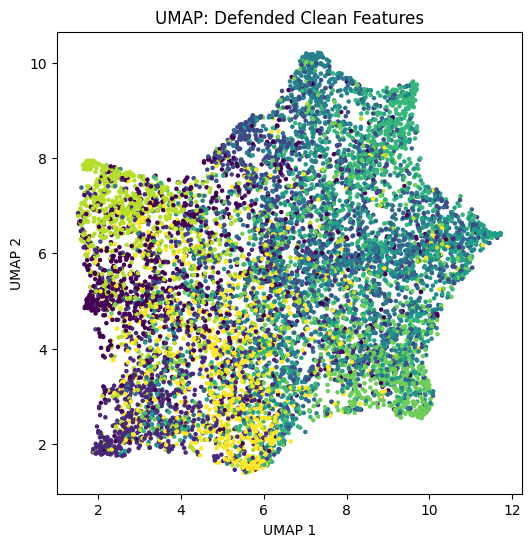

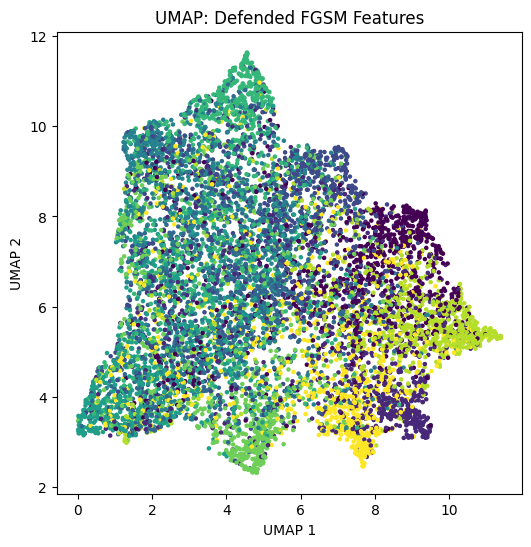

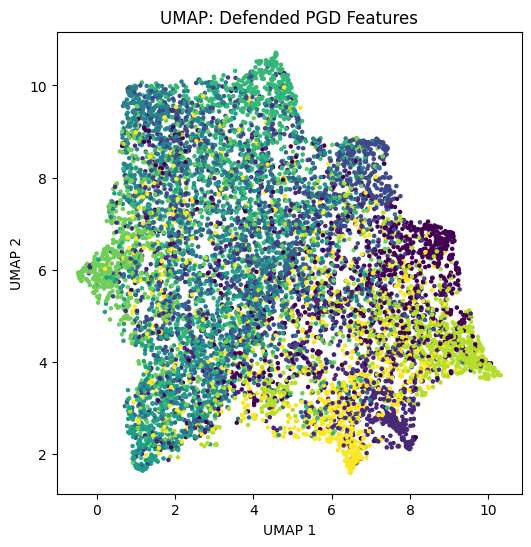

In [32]:
# Cell 7 — UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


In [33]:
import torch, torch.nn as nn, torch.optim as optim

# losses
mse_criterion = nn.MSELoss()
ce_criterion  = nn.CrossEntropyLoss()

# unfreeze everything
for p in ae.parameters():
    p.requires_grad = True
for p in classifier.parameters():
    p.requires_grad = True

# joint optimizer
optimizer_joint = optim.Adam(
    list(ae.parameters()) + list(classifier.parameters()),
    lr=1e-3
)
lambda_ce = 1.0

# joint training loop
for ep in range(1, epochs+1):
    ae.train()
    classifier.train()
    running = 0.0

    for x_raw, y in train_loader:
        x_raw, y = x_raw.to(device), y.to(device)

        # craft adversarial example on normalized raw
        x_norm    = normalize(x_raw)
        adv_norm  = fgsm(x_norm, y)
        x_adv_raw = unnormalize(adv_norm).clamp(0,1)

        # AE forward
        x_rec    = ae(x_adv_raw)
        mse_loss = mse_criterion(x_rec, x_raw)

        # classification forward (no no_grad!)
        logits   = classifier(normalize(x_rec))
        ce_loss  = ce_criterion(logits, y)

        loss = mse_loss + lambda_ce * ce_loss

        optimizer_joint.zero_grad()
        loss.backward()
        optimizer_joint.step()

        running += loss.item() * x_raw.size(0)

    avg_loss = running / len(train_loader.dataset)
    print(f"[Joint AE+CE] Epoch {ep}/{epochs}, avg loss {avg_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[Joint AE+CE] Epoch 1/10, avg loss 1.2814
[Joint AE+CE] Epoch 2/10, avg loss 1.0784
[Joint AE+CE] Epoch 3/10, avg loss 0.9944
[Joint AE+CE] Epoch 4/10, avg loss 0.9346
[Joint AE+CE] Epoch 5/10, avg loss 0.8760
[Joint AE+CE] Epoch 6/10, avg loss 0.8251
[Joint AE+CE] Epoch 7/10, avg loss 0.7853
[Joint AE+CE] Epoch 8/10, avg loss 0.7335
[Joint AE+CE] Epoch 9/10, avg loss 0.6981
[Joint AE+CE] Epoch 10/10, avg loss 0.6528


In [34]:
# Evaluation on clean, FGSM- and PGD-perturbed via AE → classifier

import torch
import torchattacks

# ensure PGD attacker is defined
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

classifier.eval()
ae.eval()

total = clean_corr = fgsm_corr = pgd_corr = 0

for x_raw, y in test_loader:
    x_raw, y = x_raw.to(device), y.to(device)
    bs = y.size(0)
    total += bs

    # — Clean
    with torch.no_grad():
        x_rec     = ae(x_raw)                            # Reconstruct clean
        logits_c  = classifier(normalize(x_rec))        # Classify
        preds_c   = logits_c.argmax(dim=1)
    clean_corr += (preds_c == y).sum().item()

    # — FGSM
    x_norm     = normalize(x_raw)
    adv_norm1  = fgsm(x_norm, y)                       # FGSM on normalized
    x_adv_raw1 = unnormalize(adv_norm1).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec1     = ae(x_adv_raw1)                    # Reconstruct FGSM
        logits_fgsm= classifier(normalize(x_rec1))
        preds_fgsm = logits_fgsm.argmax(dim=1)
    fgsm_corr += (preds_fgsm == y).sum().item()

    # — PGD
    adv_norm2  = pgd(x_norm, y)                        # PGD on normalized
    x_adv_raw2 = unnormalize(adv_norm2).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec2     = ae(x_adv_raw2)                    # Reconstruct PGD
        logits_pgd = classifier(normalize(x_rec2))
        preds_pgd  = logits_pgd.argmax(dim=1)
    pgd_corr += (preds_pgd == y).sum().item()

# compute percentages
clean_acc = 100 * clean_corr / total
fgsm_acc  = 100 * fgsm_corr  / total
pgd_acc   = 100 * pgd_corr   / total

print(f"Defended Clean accuracy: {clean_acc:.2f}%")
print(f"Defended FGSM accuracy:  {fgsm_acc:.2f}%")
print(f"Defended PGD accuracy:   {pgd_acc:.2f}%")


Defended Clean accuracy: 51.90%
Defended FGSM accuracy:  60.56%
Defended PGD accuracy:   62.73%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


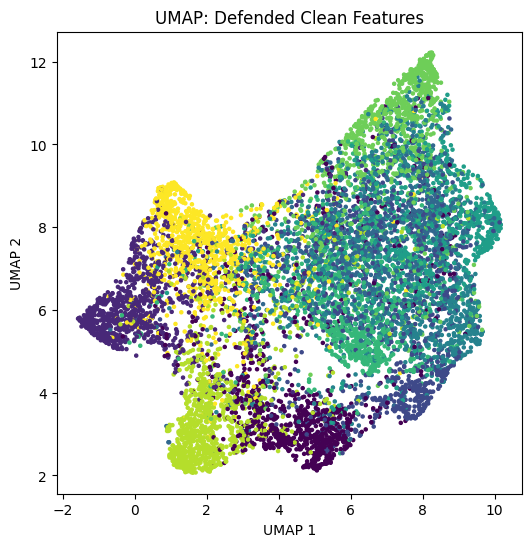

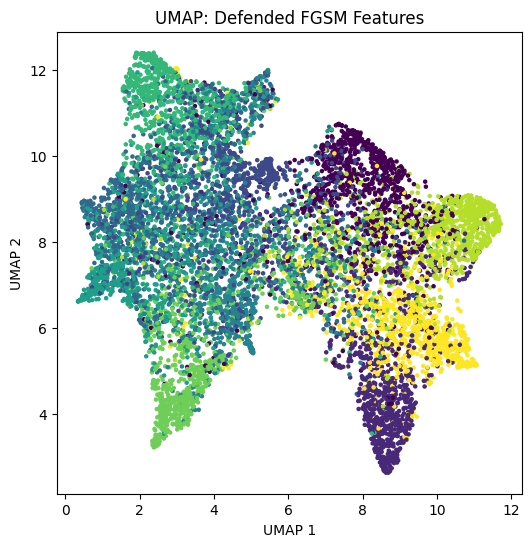

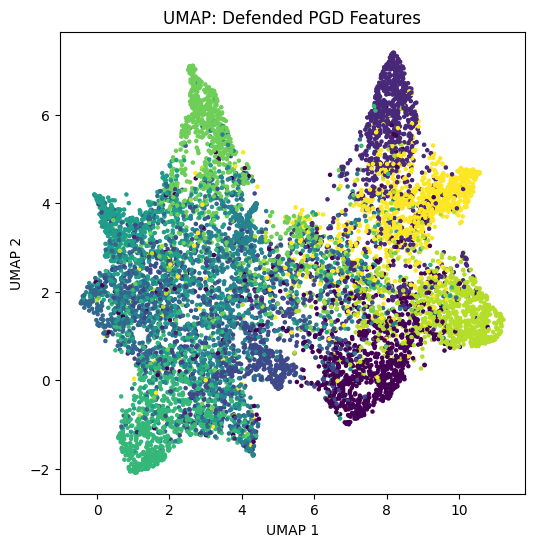

In [35]:
# Cell 7 — UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()


In [36]:
import torch.nn as nn, torch.optim as optim

# define CE loss
ce_criterion = nn.CrossEntropyLoss()

# unfreeze entire classifier
for p in classifier.parameters():
    p.requires_grad = True

opt_clf = optim.SGD(classifier.parameters(), lr=1e-3, momentum=0.9)

# fine-tune loop
for ep in range(1, epochs+1):
    classifier.train()
    running = 0.0

    for x_raw, y in train_loader:
        x_raw, y = x_raw.to(device), y.to(device)

        # reconstruct (AE frozen or trainable—depending on your choice)
        with torch.no_grad():  # keep AE fixed if you like
            x_rec = ae(x_raw)

        logits = classifier(normalize(x_rec))
        loss   = ce_criterion(logits, y)

        opt_clf.zero_grad()
        loss.backward()
        opt_clf.step()

        running += loss.item() * x_raw.size(0)

    avg = running / len(train_loader.dataset)
    print(f"[Fine-tune Classifier] Epoch {ep}, CE loss {avg:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[Fine-tune Classifier] Epoch 1, CE loss 0.5241
[Fine-tune Classifier] Epoch 2, CE loss 0.4738
[Fine-tune Classifier] Epoch 3, CE loss 0.4501
[Fine-tune Classifier] Epoch 4, CE loss 0.4340
[Fine-tune Classifier] Epoch 5, CE loss 0.4150
[Fine-tune Classifier] Epoch 6, CE loss 0.4013
[Fine-tune Classifier] Epoch 7, CE loss 0.3880
[Fine-tune Classifier] Epoch 8, CE loss 0.3767
[Fine-tune Classifier] Epoch 9, CE loss 0.3643
[Fine-tune Classifier] Epoch 10, CE loss 0.3524


In [37]:
# Evaluation on clean, FGSM- and PGD-perturbed via AE → classifier

import torch
import torchattacks

# ensure PGD attacker is defined
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

classifier.eval()
ae.eval()

total = clean_corr = fgsm_corr = pgd_corr = 0

for x_raw, y in test_loader:
    x_raw, y = x_raw.to(device), y.to(device)
    bs = y.size(0)
    total += bs

    # — Clean
    with torch.no_grad():
        x_rec     = ae(x_raw)                            # Reconstruct clean
        logits_c  = classifier(normalize(x_rec))        # Classify
        preds_c   = logits_c.argmax(dim=1)
    clean_corr += (preds_c == y).sum().item()

    # — FGSM
    x_norm     = normalize(x_raw)
    adv_norm1  = fgsm(x_norm, y)                       # FGSM on normalized
    x_adv_raw1 = unnormalize(adv_norm1).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec1     = ae(x_adv_raw1)                    # Reconstruct FGSM
        logits_fgsm= classifier(normalize(x_rec1))
        preds_fgsm = logits_fgsm.argmax(dim=1)
    fgsm_corr += (preds_fgsm == y).sum().item()

    # — PGD
    adv_norm2  = pgd(x_norm, y)                        # PGD on normalized
    x_adv_raw2 = unnormalize(adv_norm2).clamp(0,1)     # Back to pixel
    with torch.no_grad():
        x_rec2     = ae(x_adv_raw2)                    # Reconstruct PGD
        logits_pgd = classifier(normalize(x_rec2))
        preds_pgd  = logits_pgd.argmax(dim=1)
    pgd_corr += (preds_pgd == y).sum().item()

# compute percentages
clean_acc = 100 * clean_corr / total
fgsm_acc  = 100 * fgsm_corr  / total
pgd_acc   = 100 * pgd_corr   / total

print(f"Defended Clean accuracy: {clean_acc:.2f}%")
print(f"Defended FGSM accuracy:  {fgsm_acc:.2f}%")
print(f"Defended PGD accuracy:   {pgd_acc:.2f}%")


Defended Clean accuracy: 74.48%
Defended FGSM accuracy:  46.69%
Defended PGD accuracy:   48.80%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


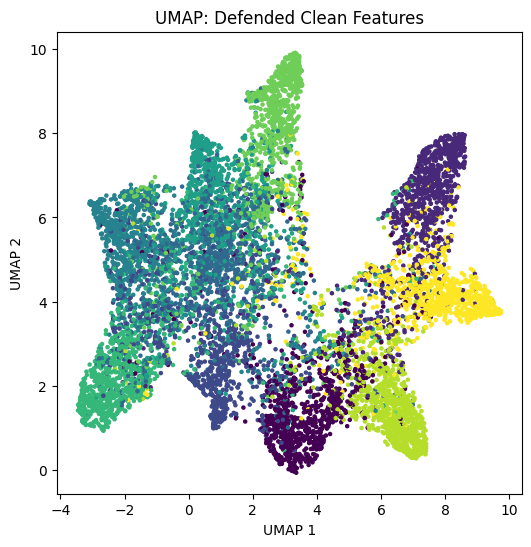

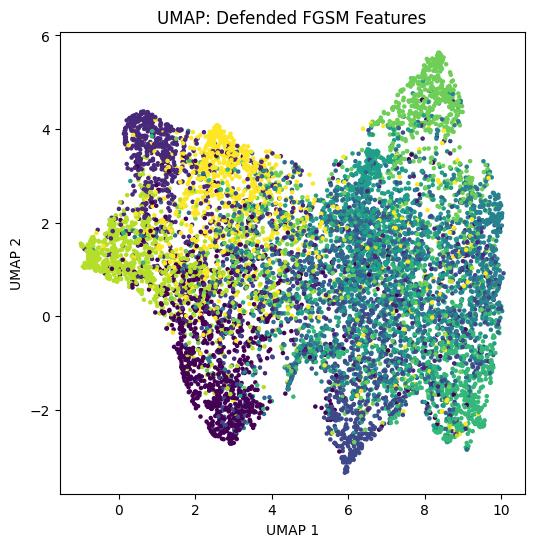

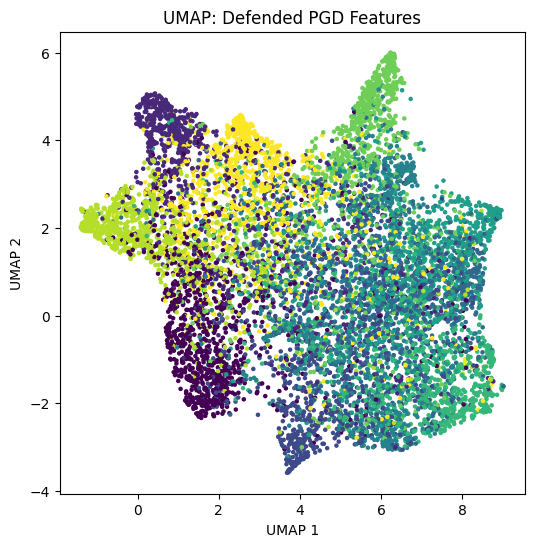

In [ ]:
#  UMAP on defended embeddings (clean, FGSM & PGD)
import torchattacks
import numpy as np
import umap
import matplotlib.pyplot as plt

# define PGD attacker (if not already defined)
eps, alpha, steps = 0.03, 0.005, 40
pgd = torchattacks.PGD(classifier, eps=eps, alpha=alpha, steps=steps)

# build feature extractor (remove FC)
feat_ext = nn.Sequential(*list(classifier.children())[:-1], nn.Flatten()).to(device)
feat_ext.eval()

# prepare containers
feats_c, lbls_c = [], []
feats_f, lbls_f = [], []
feats_p, lbls_p = [], []

for xb_raw, yb in test_loader:
    xb_raw, yb = xb_raw.to(device), yb.to(device)

    # — clean
    with torch.no_grad():
        recon_c = ae(xb_raw)
        emb_c   = feat_ext(normalize(recon_c))
    feats_c.append(emb_c.cpu());  lbls_c.append(yb.cpu())

    # — FGSM
    xb_norm   = normalize(xb_raw)
    adv_norm1 = fgsm(xb_norm, yb)
    adv_raw1  = unnormalize(adv_norm1).clamp(0,1)
    with torch.no_grad():
        recon_f = ae(adv_raw1)
        emb_f   = feat_ext(normalize(recon_f))
    feats_f.append(emb_f.cpu());  lbls_f.append(yb.cpu())

    # — PGD
    adv_norm2 = pgd(xb_norm, yb)
    adv_raw2  = unnormalize(adv_norm2).clamp(0,1)
    with torch.no_grad():
        recon_p = ae(adv_raw2)
        emb_p   = feat_ext(normalize(recon_p))
    feats_p.append(emb_p.cpu());  lbls_p.append(yb.cpu())

# stack into arrays
feats_c = np.vstack([f.numpy() for f in feats_c]);  lbls_c = np.hstack(lbls_c)
feats_f = np.vstack([f.numpy() for f in feats_f]);  lbls_f = np.hstack(lbls_f)
feats_p = np.vstack([f.numpy() for f in feats_p]);  lbls_p = np.hstack(lbls_p)

# run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
emb_c = reducer.fit_transform(feats_c)
emb_f = reducer.fit_transform(feats_f)
emb_p = reducer.fit_transform(feats_p)

# plot
for emb, lbls, title in [
    (emb_c, lbls_c, "UMAP: Defended Clean Features"),
    (emb_f, lbls_f, "UMAP: Defended FGSM Features"),
    (emb_p, lbls_p, "UMAP: Defended PGD Features"),
]:
    plt.figure(figsize=(6,6))
    plt.scatter(emb[:,0], emb[:,1], c=lbls, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.show()
